# makemore MLP
following the lines of paper: https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf

In [315]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [316]:
# read in all the words
words = open('../name.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [317]:
len(words)

32033

In [318]:
# build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
# build the dataset
block_size = 3  # context length: how many characters do we take to predict the next one
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1 : n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [320]:
C = torch.randn((27, 2))
emb = C[Xtr]

In [321]:
# torch index examples
# print(F.one_hot(torch.tensor(5), num_classes=27).float() @ C)
# print(C[5])
# print(C[[5, 6, 7]])
# print(C[torch.tensor([5, 6 ,7])])
# print(C[torch.tensor([[5, 6 ,7], [5, 6, 7]])])

# C[X[x, y]] == C[X][x, y]
# print(C[X].shape)
# print(X[13, 2])
# print(C[X][13, 2])
# print(C[1])
# print(C[X[13, 2]])

In [322]:
# 6: each character is of 2 dims, we are using 3 preceding characters
#    to predict the next one, so the inputs is of 3 * 2 = 6 dims
# 100: the size of the hidden layer
W1 = torch.randn((6, 100))
b1 = torch.randn(100)
# emb @ W1 + b1
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [323]:
# notes: how to acheive `emb @ W1 + b1`
print(emb.shape)
print(W1.shape)
print(b1.shape)

# naive approach
# torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1)
# equivalently
# torch.cat(torch.unbind(emb, dim=1), dim=1)

# introduce `view` which does not create new storage for the tensor
# a = emb.view(32, 6)
# emb.view(32, 6) == torch.cat(torch.unbind(emb, dim=1), dim=1)
# equivalently
# b = emb.view(-1, 6)



torch.Size([182625, 3, 2])
torch.Size([6, 100])
torch.Size([100])


In [324]:
# W2 = torch.randn((100, 27))
# b2 = torch.randn(27)
# logits = h @ W2 + b2
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdims=True)
# loss = - prob[torch.arange(32), Y].log().mean()

In [325]:
# ------------------- now made respectable ------------------
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [326]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True


In [327]:
sum(p.nelement() for p in parameters)

11897

In [328]:
lossi = []
stepsi = []

In [329]:
for i in range(200000):
    # minibatch construction
    ix = torch.randint(0, Xtr.shape[0], (32,))    # mini batch size = 32

    # forward pass 
    emb = C[Xtr[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)   # (32, 100)
    logits = h @ W2 + b2    # (32, 27)
    # why use F.cross_entropy not handrolled?
    # 1. forwrd and backward pass more efficient;
    #    no intermediate tensors like counts, prob, etc.
    # 2. mathmatically more behaved;
    #    e.x. [-100, 3, 5, 100].exp() -> [...,...,..., nan]
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    stepsi.append(i)
    lossi.append(loss.log10().item())
# print(loss.item())

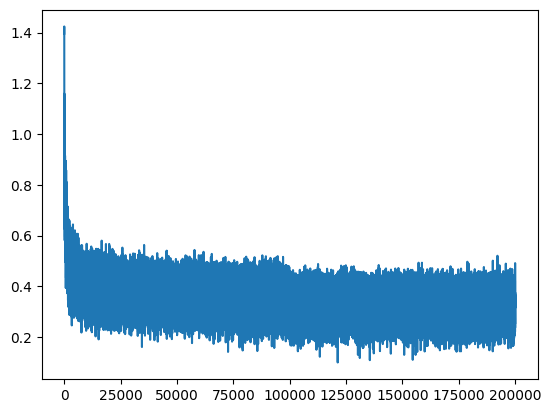

In [330]:
plt.plot(stepsi, lossi)

In [331]:

emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1202, grad_fn=<NllLossBackward0>)

In [332]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
# training parameters, find hyper-parameters, to test sparsely
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1608, grad_fn=<NllLossBackward0>)

In [333]:
g = torch.Generator().manual_seed(214748364 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]    # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))


nity.
fadhity.
codona.
ron.
olowan.
lareyan.
marci.
nove.
iiauriah.
heel.
grugefringsuran.
nuor.
isha.
sano.
ansi.
ane.
liya.
onalyashanarth.
tilla.
falon.
